# SOUS VIDE Examples Notebook
This notebook shows you how to generate two example policies from the SOUS VIDE paper; the policy flown for the robustness tests and the policy flown in the cluttered backroom.

Some useful settings for interactive work

In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib widget

Import the relevant modules

In [2]:
import torch
torch.set_float32_matmul_precision('high')

import sousvide.synthesize.rollout_generator as rg
import sousvide.synthesize.observation_generator as og
import sousvide.instruct.train_policy as tp
import sousvide.visualize.plot_synthesize as ps
import sousvide.visualize.plot_learning as pl
import sousvide.flight.deploy_figs as df

#### 1. Define the desired scene and course to train on.

In [3]:
# =========================================
# Aerial Arena Test
# =========================================

# cohort = "aerial_arena"               # Cohort name (parent folder) for the robustness test
# scene = "aerialarena_square_16x/splatfacto/2026-08-06_013130_clean"                  # Scene name for the robustness test
# courses = ["aerialarena_test"]              # Courses to be used in the robustness test

# =========================================
# Robustness Test
# =========================================

cohort = "robustness"               # Cohort name (parent folder) for the robustness test
scene = "mid_gate"                  # Scene name for the robustness test
courses = ["traverse"]              # Courses to be used in the robustness test

# # =========================================
# # Cluttered Test
# # =========================================

# cohort = "cluttered"               # Cohort name (parent folder) for the cluttered test
# scene = "backroom"                  # Scene name for the cluttered test
# courses = ["circuit"]              # Courses to be used in the cluttered test

#### 2. Define the SOUS VIDE policy to train/evaluate.

Feel free to use Maverick as a reference to add more pilots in the configs/pilots folder. The configs allow users to create diverse variations of the policy without having to change package level code. We have an example of this (Iceman) where we remove velocity and height estimates.

Use data_alpha for your data method as a small initial test. It gives performance close to the published results within a shorter training time. Use data_beta/data_gamma to generate the actual policy (this takes longer, up to a day depending on your hardware setup).

Similarly, feel free to play with the eval methods according to their incremental difficulties.

In [4]:
# Pilot roster
roster = [
    "Maverick",
    # "Iceman"
    ]

# Data synthesis method.
# data_method = "data_alpha"          # Small data set for initial testing (use only to get a feel for the system).
data_method = "data_beta"           # Medium data set for training
# data_method = "data_gamma"          # Large data set for training

# Evaluation methods
# eval_method = "eval_single"         # Evaluate over a single trajectory, ideal frame and no noise.
eval_method = "eval_nominal"        # Evaluate over 10 trajectories, non-ideal frame and noise.
# eval_method = "eval_challenged"     # Evaluate over 10 trajectories, non-ideal frame and some noise.
# # eval_method = "eval_extreme"        # Evaluate over 10 trajectories after putting the drone and pilot through a washing machine.

#### 3. Generate trajectory rollouts.

Trajectory rollouts are the raw data we extract from the simulation environment, FiGS. This comprises of images, states, inputs, external forces, drone parameters and their derivations.

We also output the ideal trajectory and the solved (ideal) keyframe times given the desired waypoints (course).

Use the given plot function to plot the rollout data. It gives some insight on the currently available rollout data within the cohort.

In [ ]:
import numpy
torch.serialization.add_safe_globals([numpy.core.multiarray.scalar])

# Generate Rollout Data
rg.generate_rollout_data(cohort,courses,scene,data_method,generate_events=True,event_workers=10)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


Loading latest checkpoint from load_dir

✅ Done loading checkpoint from outputs/mid_gate/splatfacto/2024-10-07_145741/nerfstudio_models/step-000029999.ckpt

Output()

 traverse - Ideal Time Steps: [ 0.     3.752  6.606  9.163 12.16  14.164]

...

Simulating vrmpc rollout:   0%|          | 0/200 [00:00<?, ?it/s]

Simulating vrmpc rollout:   0%|          | 0/200 [00:00<?, ?it/s]

Simulating vrmpc rollout:   0%|          | 0/200 [00:00<?, ?it/s]

Simulating vrmpc rollout:   0%|          | 0/200 [00:00<?, ?it/s]

Simulating vrmpc rollout:   0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:

# Review the Rollout Data
# ps.plot_rollout_data(cohort)

In [ ]:
# # Inspect one Kronecker-delta frame from a chosen stack.
# from pathlib import Path
# import matplotlib.pyplot as plt
# import sousvide.synthesize.data_compress_helper as dch

# workspace_path = Path(rg.__file__).resolve().parents[3]
# kronecker_pt = workspace_path / "cohorts" / cohort / "rollout_data" / courses[0] / "kronecker" / "kronecker011.pt"
# rollout_index = 0
# # frame_index = 30
# kronecker_stack = torch.load(kronecker_pt, weights_only=False, encoding="bytes")
# rollout = dch.decompress_data(dict(kronecker_stack[rollout_index]), key="kronecker_delta")
# frames = rollout["kronecker_delta"]
# for frame_index in range(len(frames)):
#     if not 0 <= frame_index < len(frames):
#         raise IndexError(f"frame_index {frame_index} is outside [0, {len(frames) - 1}]")

#     image = frames[frame_index]
#     if image.ndim != 2:
#         raise ValueError(f"Expected a grayscale (H, W) frame, got {image.shape}")

#     fig, ax = plt.subplots(figsize=(8, 5))
#     ax.imshow(image, cmap="gray", vmin=0, vmax=255)
#     ax.set_title(f"{kronecker_pt.name} | rollout {rollout['rollout_id']} | frame {frame_index}")
#     ax.axis("off")
#     plt.show()

# print(f"Loaded {kronecker_pt}")
# print(f"Frame shape: {image.shape}, dtype: {image.dtype}, nonzero pixels: {(image > 0).sum()}")

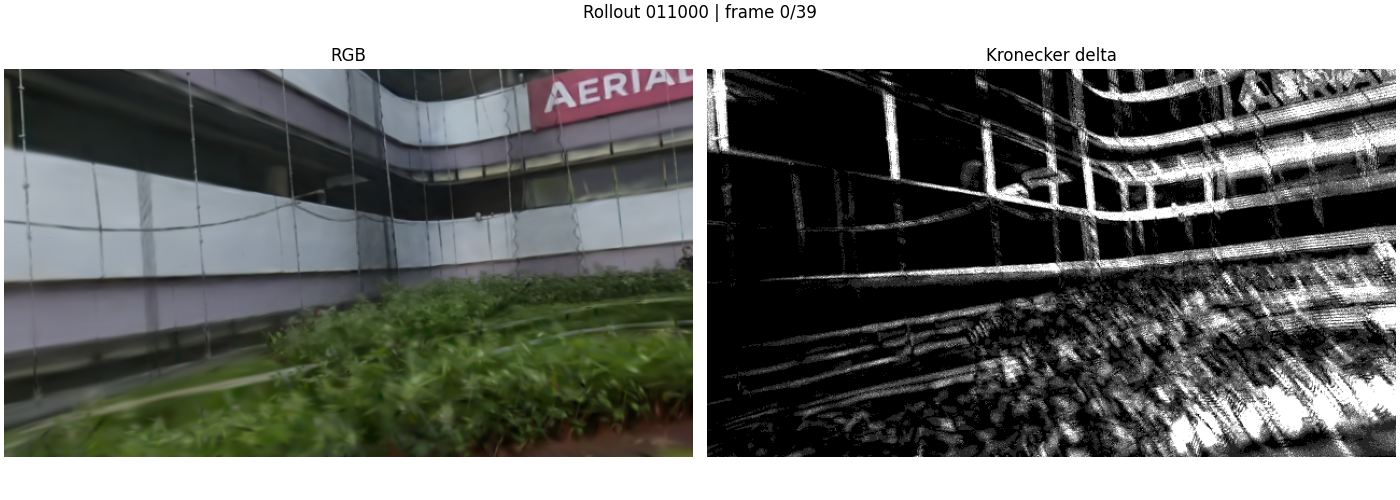

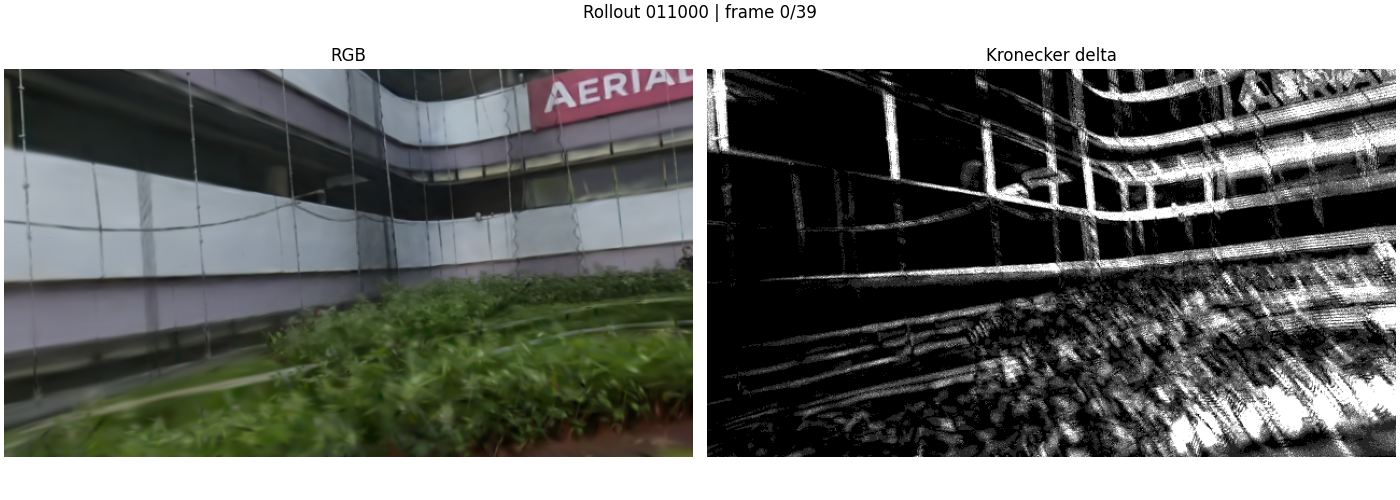

In [ ]:
# # Compare the RGB and Kronecker-delta frames for one rollout.
# import ipywidgets as widgets
# from IPython.display import display

# rollout_index = 0  # Index within the stack selected by kronecker_pt above.
# playback_interval_ms = 100

# stack_suffix = kronecker_pt.name.removeprefix("kronecker")
# rgb_pt = kronecker_pt.parent.parent / "images" / f"images{stack_suffix}"
# rgb_stack = torch.load(rgb_pt, weights_only=False, encoding="bytes")

# if not 0 <= rollout_index < len(kronecker_stack):
#     raise IndexError(
#         f"rollout_index {rollout_index} is outside the Kronecker stack range "
#         f"[0, {len(kronecker_stack) - 1}]"
#     )
# if rollout_index >= len(rgb_stack):
#     raise IndexError(
#         f"rollout_index {rollout_index} is outside the RGB stack range "
#         f"[0, {len(rgb_stack) - 1}]"
#     )

# rgb_rollout = dch.decompress_data(dict(rgb_stack[rollout_index]), key="rgb")
# kronecker_rollout = dch.decompress_data(
#     dict(kronecker_stack[rollout_index]), key="kronecker_delta"
# )
# if rgb_rollout["rollout_id"] != kronecker_rollout["rollout_id"]:
#     raise ValueError(
#         f"Rollout IDs do not match: {rgb_rollout['rollout_id']} != "
#         f"{kronecker_rollout['rollout_id']}"
#     )

# rgb_frames = rgb_rollout["rgb"]
# kronecker_frames = kronecker_rollout["kronecker_delta"]
# if len(rgb_frames) != len(kronecker_frames):
#     raise ValueError(
#         f"Frame counts do not match: RGB={len(rgb_frames)}, "
#         f"Kronecker-delta={len(kronecker_frames)}"
#     )
# if len(rgb_frames) == 0:
#     raise ValueError(f"Rollout {rgb_rollout['rollout_id']} has no frames")

# fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
# rgb_artist = axes[0].imshow(rgb_frames[0])
# kronecker_artist = axes[1].imshow(
#     kronecker_frames[0], cmap="gray", vmin=0, vmax=255
# )
# axes[0].set_title("RGB")
# axes[1].set_title("Kronecker delta")
# for axis in axes:
#     axis.axis("off")
# frame_title = fig.suptitle("")

# def show_aligned_frames(frame_index):
#     rgb_artist.set_data(rgb_frames[frame_index])
#     kronecker_artist.set_data(kronecker_frames[frame_index])
#     frame_title.set_text(
#         f"Rollout {rgb_rollout['rollout_id']} | frame {frame_index}/{len(rgb_frames) - 1}"
#     )
#     fig.canvas.draw_idle()

# frame_slider = widgets.IntSlider(
#     value=0, min=0, max=len(rgb_frames) - 1, step=1,
#     description="Frame", continuous_update=False,
# )
# play_button = widgets.Play(
#     value=0, min=0, max=len(rgb_frames) - 1, step=1,
#     interval=playback_interval_ms, description="Play",
# )
# play_link = widgets.link((play_button, "value"), (frame_slider, "value"))
# frame_slider.observe(
#     lambda change: show_aligned_frames(change["new"]), names="value"
# )
# show_aligned_frames(0)
# display(widgets.HBox([play_button, frame_slider]))
# display(fig.canvas)

#### 4. Extract observation data.

We next extract the relevant data for each pilot. Users can configure their learned policies to use a variety of inputs. This function call extracts said inputs specific to each pilot from the raw rollout data. This allows you to test multiple learned policies from a single set of raw rollouts.

In [ ]:
# Generate Observation Data
og.generate_observation_data(cohort,roster)

#### 5. Train the histNet

The best policy we found has two distinct networks that are trained separately. Here we train the first network, the histNet, which does a form of online rapid-motor-adaptation using a latent estimate of the drone's parameters. You can run the train_roster command multiple times to continue training the histNet. If you want to start from scratch, simply delete the histNet in the corresponding $course/roster/$pilot folder.

Use the plot function to review the current network's train/eval losses.

In [ ]:
# Train the Policy
tp.train_roster(cohort,roster,"histNet",200)

# Plot the histNet losses
pl.plot_losses(cohort,roster,"histNet",use_log=True)

#### 6. Train the commNet

Here we train the second network, commNet, which contains the bulk of the parameters for the visuomotor policy. We also show a deployment evaluation option for training where we simulate the policy in FiGS at the save intervalsand use trajectory tracking error to grade policy performance. The best performing policy will be the final one that gets saved. Just like with histNet, re-running the train_roster function will load and train an existing network and if you want to start from scratch, delete the commNet file in the corresponding $course/roster/$pilot folder.

It is important to note that regen should be set to True every time you start training commNet right after a histNet training session. This is because the outputs of the histNet network will have changed.

Use the plot function to review the current network's train/eval losses.

In [ ]:
# Train the Policy
tp.train_roster(
    cohort,roster,"commNet",300,
    regen=True,
    deployment=(courses[0],scene,eval_method),image_modality="kronecker_delta",batch_size=256)

# Plot the commNet losses
pl.plot_losses(cohort,roster,"commNet",use_log=True)

#### 7. Evaluate using FiGS

Run an evalution using FiGS simulations and plot some useful data. Video of last policy rollout(s) can be found in $course/deployment_data.

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


Loading latest checkpoint from load_dir

✅ Done loading checkpoint from 
outputs/aerialarena_square_16x/splatfacto/2026-08-06_013130_clean/nerfstudio_models/step-000059999.ckpt

/home/airlab/SousVide/.venv/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


Generating network 'histNet' of type 'sifu' at path '/home/airlab/SousVide/cohorts/aerial_arena/roster/Maverick/histNet.pt'...
Generating network 'commNet' of type 'svnet' at path '/home/airlab/SousVide/cohorts/aerial_arena/roster/Maverick/commNet_rgb.pt'...


Simulating Maverick:   0%|          | 0/10 [00:00<?, ?it/s]

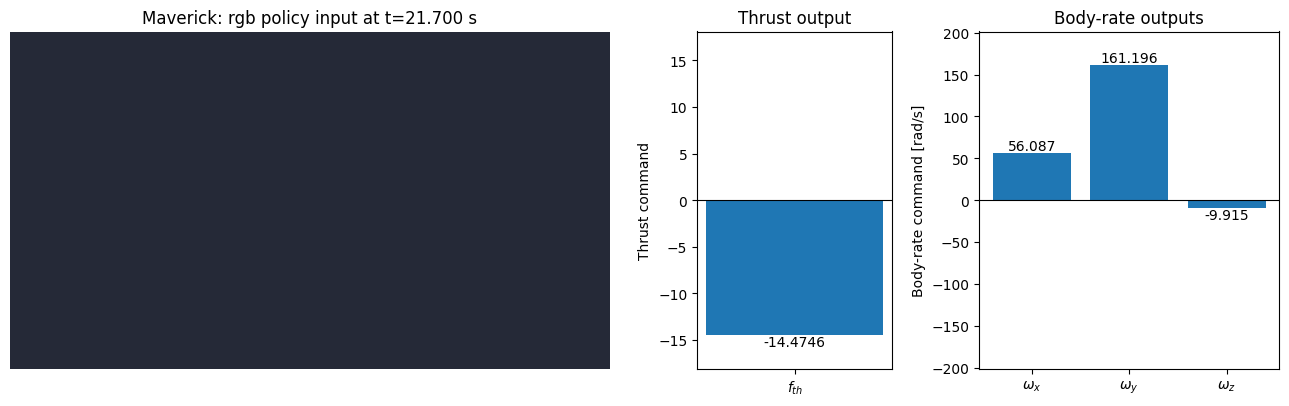

Pilot expert does not have a deployment.

Plotting trajectories for Maverick...

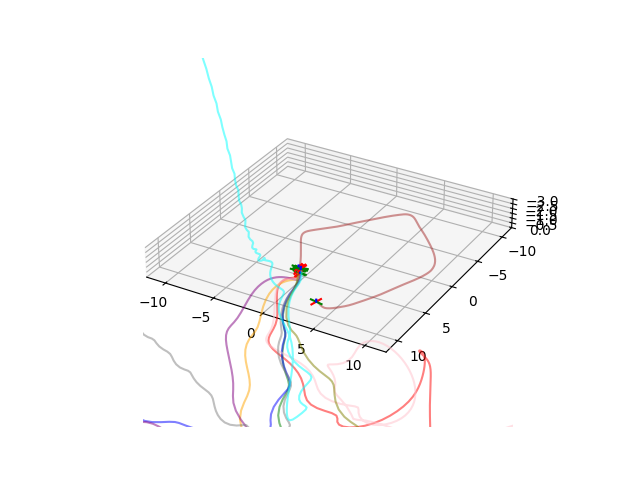

                      Deployment Summary                      
┏━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┓
┃ Pilot    ┃ TTE Mean ┃ TTE Best ┃  PP  ┃ Hz Mean ┃ Hz Worst ┃
┡━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━╇━━━━━━━━━╇━━━━━━━━━━┩
│ Maverick │  626.71  │  16.84   │ 0.00 │  1.41   │   1.36   │
└──────────┴──────────┴──────────┴──────┴─────────┴──────────┘

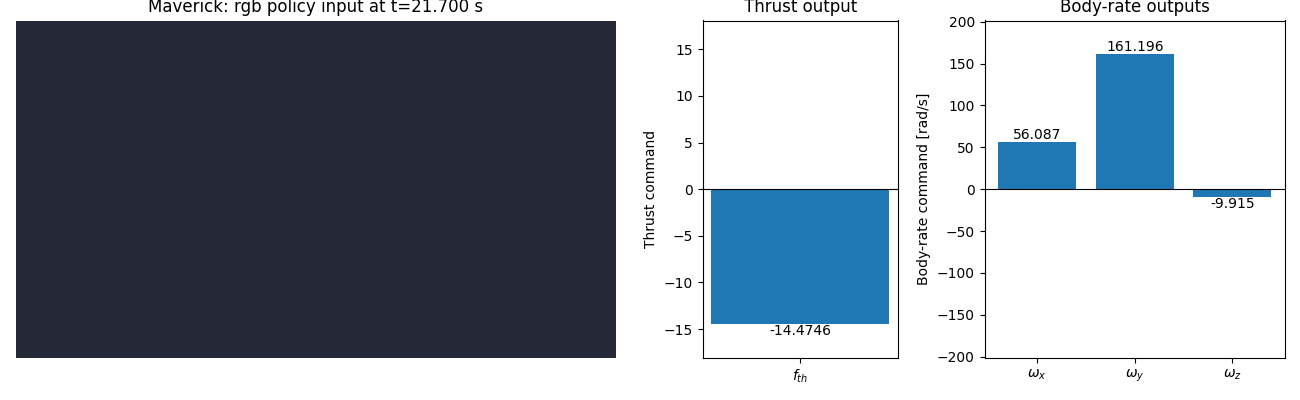

In [8]:
# Simulate in FiGS
debug_deployment = True  # Set True to show the live policy image and body-rate output.

for course in courses:
    df.deploy_roster(
        cohort,course,scene,eval_method,roster,mode="visualize",
        image_modality="rgb",debug=debug_deployment)
    pl.plot_deployments(cohort,course,roster,plot_show=True)